<a href="https://colab.research.google.com/github/shurajkr1412/NGS/blob/main/Feature%20Engineering%20%26%20Dimensionality%20Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip install pandas numpy scikit-learn umap-learn matplotlib seaborn plotly

# Import libraries with clear names
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 7)
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load a public metabolomics dataset directly from URL
# Dataset: Human cachexia (muscle wasting) urine NMR metabolomics
# Classes: Cachexia (disease) vs Control (healthy)
# Source: MetaboAnalyst example dataset

url = "https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv"

# Read the CSV file
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape of data: {df.shape}  (rows = samples, columns = metabolites + metadata)")
print("\nFirst and last 5 rows:")
display(df.head(77))

# Show column information
print("\nColumns in the dataset:")
print(df.columns.tolist()[:10], "... and more")

Dataset loaded successfully!
Shape of data: (77, 65)  (rows = samples, columns = metabolites + metadata)

First and last 5 rows:


,Patient ID,Muscle loss,"1,6-Anhydro-beta-D-glucose",1-Methylnicotinamide,2-Aminobutyrate,2-Hydroxyisobutyrate,2-Oxoglutarate,3-Aminoisobutyrate,3-Hydroxybutyrate,3-Hydroxyisovalerate,...,Tryptophan,Tyrosine,Uracil,Valine,Xylose,cis-Aconitate,myo-Inositol,trans-Aconitate,pi-Methylhistidine,tau-Methylhistidine
0,PIF_178,cachexic,40.85,65.37,18.73,26.05,71.52,1480.30,56.83,10.07,...,259.82,290.03,111.05,86.49,72.24,237.46,135.64,51.94,157.59,160.77
1,PIF_087,cachexic,62.18,340.36,24.29,41.68,67.36,116.75,43.82,79.84,...,83.10,167.34,46.99,109.95,192.48,333.62,376.15,217.02,307.97,130.32
2,PIF_090,cachexic,270.43,64.72,12.18,65.37,23.81,14.30,5.64,23.34,...,82.27,60.34,31.50,59.15,2164.62,330.30,86.49,58.56,145.47,83.93
3,NETL_005_V1,cachexic,154.47,52.98,172.43,74.44,1199.91,555.57,175.91,25.03,...,235.10,323.76,30.57,102.51,125.21,1863.11,247.15,75.94,249.64,254.68
4,PIF_115,cachexic,22.20,73.70,15.64,83.93,33.12,29.67,76.71,69.41,...,103.54,142.59,44.26,160.77,186.79,101.49,749.95,98.49,84.77,79.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,NETCR_019_V2,control,35.16,52.46,13.87,44.26,99.48,208.51,11.25,6.49,...,46.06,45.15,62.18,33.45,62.80,103.54,78.26,18.17,871.31,84.77
73,NETL_012_V1,control,16.95,15.80,10.49,22.42,62.80,10.91,6.96,3.46,...,21.33,21.33,31.19,13.20,14.30,36.23,11.59,12.30,53.52,44.70
74,NETL_012_V2,control,9.39,14.01,5.16,23.57,46.99,13.33,3.35,2.69,...,14.88,15.18,39.65,13.74,21.76,40.85,30.88,8.50,90.02,28.22
75,NETL_003_V1,control,37.71,18.17,26.05,15.03,23.34,33.45,6.05,5.26,...,17.46,29.96,13.46,14.59,36.97,90.92,17.64,12.43,897.85,90.02



Columns in the dataset:
['Patient ID', 'Muscle loss', '1,6-Anhydro-beta-D-glucose', '1-Methylnicotinamide', '2-Aminobutyrate', '2-Hydroxyisobutyrate', '2-Oxoglutarate', '3-Aminoisobutyrate', '3-Hydroxybutyrate', '3-Hydroxyisovalerate'] ... and more


In [3]:
# In omics data:
# - First few columns are usually metadata (Sample ID, Class label)
# - Remaining columns are features (metabolite concentrations)

# Separate features (metabolites) and labels (Cachexic vs Control)
metadata_cols = ['Patient ID', 'Muscle loss']   # Adjust if column names differ slightly
features = df.drop(columns=metadata_cols)
labels = df['Muscle loss']

print(f"Number of samples: {features.shape[0]}")
print(f"Number of metabolites (features): {features.shape[1]}")
print(f"Class distribution:\n{labels.value_counts()}")

Number of samples: 77
Number of metabolites (features): 63
Class distribution:
Muscle loss
cachexic    47
control     30
Name: count, dtype: int64


In [4]:
# Why scale? Metabolites have different concentration ranges.
# Without scaling, high-abundance metabolites dominate the analysis.

scaler = StandardScaler()      # This makes mean=0, std=1 for each metabolite
X_scaled = scaler.fit_transform(features)

print("Data scaled successfully!")
print("Now all metabolites contribute equally to the analysis.")

print(f"Shape of data ready for dimensionality reduction: {X_scaled.shape} (samples x metabolites)")

Data scaled successfully!
Now all metabolites contribute equally to the analysis.
Shape of data ready for dimensionality reduction: (77, 63) (samples x metabolites)


In [5]:
from sklearn.decomposition import PCA

# Apply PCA directly on the scaled data
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Show how much information the first two components capture
explained = pca.explained_variance_ratio_

print("PCA completed!")
print(f"PC1 explains {explained[0]*100:.1f}% of the variance")
print(f"PC2 explains {explained[1]*100:.1f}% of the variance")
print(f"Total variance captured in 2D: {sum(explained)*100:.1f}%")

PCA completed!
PC1 explains 40.4% of the variance
PC2 explains 8.2% of the variance
Total variance captured in 2D: 48.6%


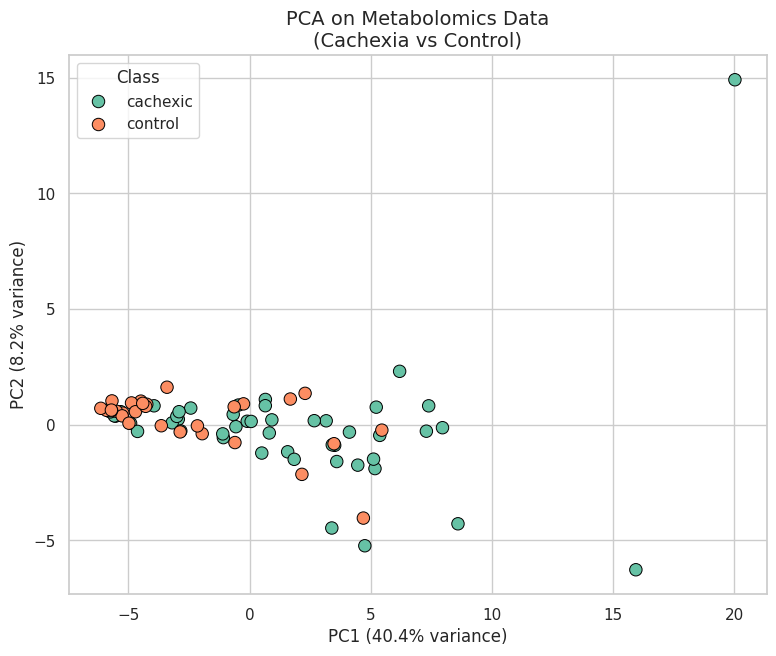

In [6]:
# Visualization
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=labels,
    palette='Set2',
    s=80,
    edgecolor='black'
)

plt.title('PCA on Metabolomics Data\n(Cachexia vs Control)', fontsize=14)
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
plt.legend(title='Class')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


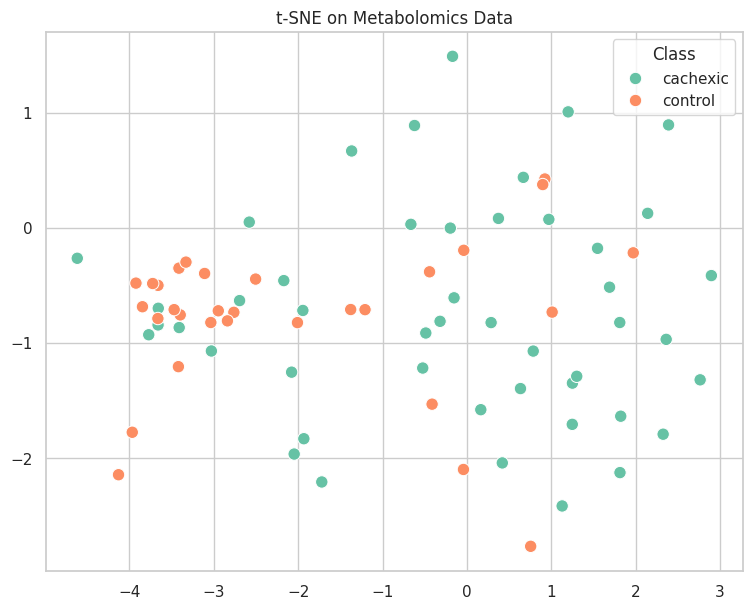

In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels,
    palette='Set2',
    s=80
)

plt.title('t-SNE on Metabolomics Data')
plt.legend(title='Class')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


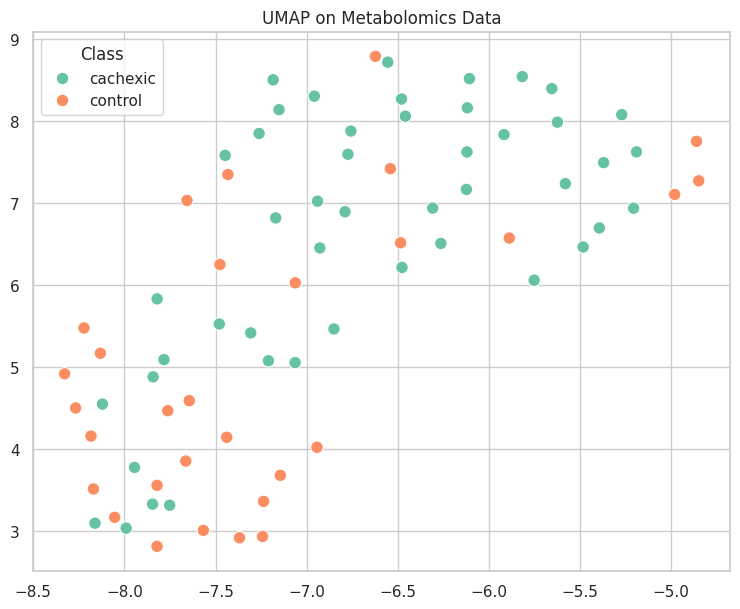

In [8]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=labels,
    palette='Set2',
    s=80
)

plt.title('UMAP on Metabolomics Data')
plt.legend(title='Class')
plt.show()

In [9]:
# Show which metabolites drive PCA separation (Loadings)
print("\nTop 5 metabolites contributing most to PC1 (biological drivers):")

loadings = pd.Series(pca.components_[0], index=features.columns)
print(loadings.abs().sort_values(ascending=False).head(5))


Top 5 metabolites contributing most to PC1 (biological drivers):
Creatinine      0.175497
Glutamine       0.170896
Ethanolamine    0.170418
Asparagine      0.169160
Threonine       0.168460
dtype: float64
